In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, f1_score

In [3]:
df = pd.read_csv("/content/1) iris.csv")
df.head(), df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


(   sepal_length  sepal_width  petal_length  petal_width species
 0           5.1          3.5           1.4          0.2  setosa
 1           4.9          3.0           1.4          0.2  setosa
 2           4.7          3.2           1.3          0.2  setosa
 3           4.6          3.1           1.5          0.2  setosa
 4           5.0          3.6           1.4          0.2  setosa,
 None)

In [4]:
X = df.drop('species', axis=1)
y = df['species']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [7]:
y_pred = model.predict(X_test)

print("\nBase Model Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Base Model Performance:
Accuracy: 1.0
F1 Score: 1.0

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



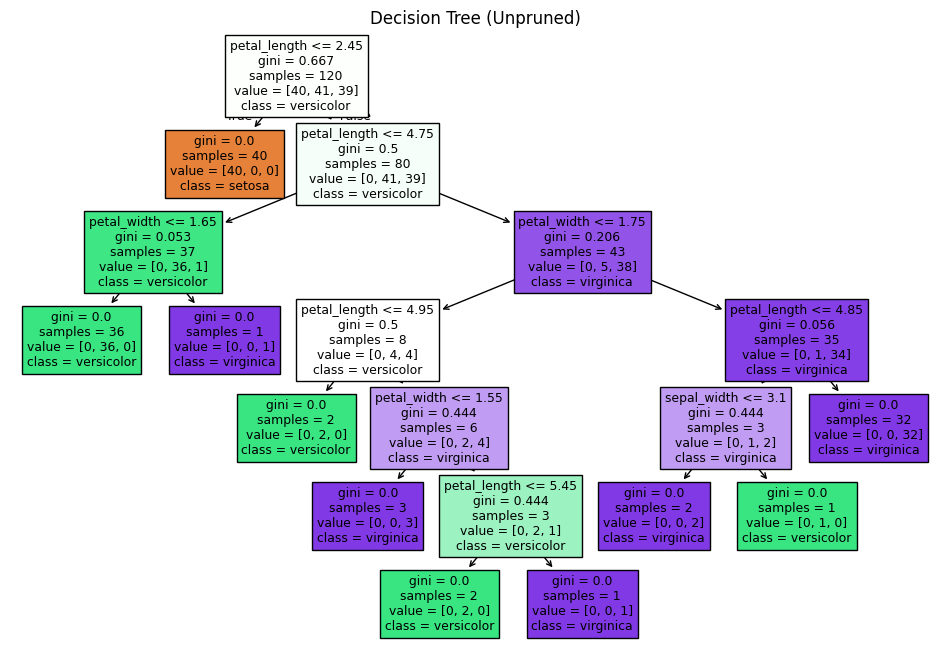

In [8]:
plt.figure(figsize=(12,8))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=y.unique(),
    filled=True
)
plt.title("Decision Tree (Unpruned)")
plt.show()


In [9]:
pruned_model = DecisionTreeClassifier(
    max_depth=3,          # 🔥 key control
    min_samples_split=5,
    random_state=42
)

pruned_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, min_samples_split=5, random_state=42)

In [10]:
y_pred_pruned = pruned_model.predict(X_test)

print("\nPruned Model Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_pruned))
print("F1 Score:", f1_score(y_test, y_pred_pruned, average='weighted'))


Pruned Model Performance:
Accuracy: 1.0
F1 Score: 1.0


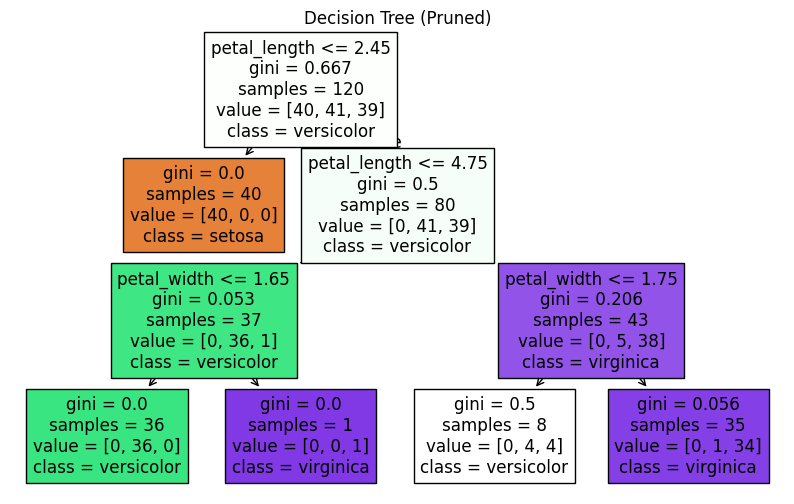

In [11]:
plt.figure(figsize=(10,6))
plot_tree(
    pruned_model,
    feature_names=X.columns,
    class_names=y.unique(),
    filled=True
)
plt.title("Decision Tree (Pruned)")
plt.show()